#Day23. 머신러닝기초
---

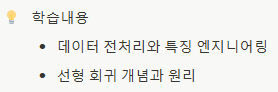

#**데이터 전처리와 특징 엔지니어링**

머신러닝 모델의 성능은 데이터의 품질에 크게 의존  
데이터를 제대로 정리하고, 적절한 특징(Feature)을 만들어내는 과정이 매우 중요  
이를 위해 데이터 전처리(Data Preprocessing) & 특징 엔지니어링(Feature Engineering) 수행

##**데이터 전처리 (Data Preprocessing)**

원시 데이터를 머신러닝 모델에 적합한 형태로 변환하는 과정  
데이터에는 결측값, 이상치, 중복 데이터 등이 포함될 수 있으며, 이를 처리해야 모델이 효과적으로 학습 가능

**1) 데이터 정리 및 탐색**

데이터를 정리하고 구조를 이해하는 단계

- **데이터 로드**: pandas, NumPy 등을 활용하여 데이터를 불러옴
- **기초 통계 확인**: `df.describe()`, `df.info()` 등을 이용하여 데이터 타입과 분포 확인
- **데이터 시각화**: matplotlib, seaborn을 사용해 변수 간 관계 파악

**2) 결측값(Missing Values) 처리**

결측값은 데이터셋에 값이 없는 부분을 의미하며, 적절히 처리하지 않으면 모델의 성능이 저하될 수 있음

결측값 확인

```python
import pandas as pd
df.isnull().sum()  # 결측값 개수 확인
```

결측값 처리 방법

- **삭제(Dropping)**: 결측값이 적은 경우 해당 행 또는 열 제거
    
    ```python
    df.dropna(inplace=True)
    ```
    
- **대체(Imputation)**: 평균, 중앙값, 최빈값 또는 예측값으로 결측값을 채움
    
    ```python
    df.fillna(df.mean(), inplace=True)  # 평균값으로 대체
    df.fillna(df.median(), inplace=True)  # 중앙값으로 대체
    df.fillna(df.mode().iloc[0], inplace=True)  # 최빈값으로 대체
    ```
    
- **예측 모델 활용**: 머신러닝 모델을 이용해 결측값을 예측하고 보완

**3) 이상치(Outliers) 처리**

이상치는 데이터 분포에서 벗어난 극단적인 값으로, 모델 성능을 저하시킬 수 있음

이상치 탐색

- **박스플롯(Box Plot)** 활용
    
    ```python
    import seaborn as sns
    sns.boxplot(x=df['feature_column'])
    ```
    
- **Z-Score 활용**
    
    ```python
    from scipy import stats
    z_scores = stats.zscore(df['feature_column'])
    df = df[(z_scores < 3)]  # Z-score가 3 이상이면 이상치로 간주하여 제거
    ```
    
- **IQR(Interquartile Range, 사분위 범위) 활용**
    
    ```python
    Q1 = df['feature_column'].quantile(0.25)
    Q3 = df['feature_column'].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df['feature_column'] >= Q1 - 1.5 * IQR) & (df['feature_column'] <= Q3 + 1.5 * IQR)]
    ```
    

이상치 처리 방법

- **제거(Removal)**: 이상치를 제거하는 방식
- **대체(Replacement)**: 중앙값 또는 평균값으로 변경
- **변환(Transformation)**: 로그 변환, 제곱근 변환 등 사용

**4) 데이터 정규화 및 스케일링**

특징 값(Feature Value)의 크기가 다를 경우 모델 성능에 영향을 미칠 수 있으므로 스케일링을 수행해야 함

정규화(Normalization)

- 모든 값을 0~1 범위로 변환
- `MinMaxScaler` 사용
    
    ```python
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    df[['feature1', 'feature2']] = scaler.fit_transform(df[['feature1', 'feature2']])
    ```
    

표준화(Standardization)

- 평균이 0, 표준편차가 1이 되도록 변환
- `StandardScaler` 사용
    
    ```python
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    df[['feature1', 'feature2']] = scaler.fit_transform(df[['feature1', 'feature2']])
    ```
    

##**특징 엔지니어링 (Feature Engineering)**

모델이 학습할 수 있도록 적절한 특징을 생성하거나 변환하는 과정

**1) 새로운 특징 생성**

새로운 변수(Feature)를 추가하여 모델의 성능을 향상할 수 있습니다.

기존 변수 조합

- 예) 키와 몸무게를 이용해 BMI(체질량지수) 생성
    
    ```python
    df['BMI'] = df['Weight'] / (df['Height']**2)
    ```
    

날짜 정보 변환

- 날짜 데이터를 요일, 월, 연도 등으로 변환
    
    ```python
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['weekday'] = df['date'].dt.weekday  # 0: 월요일, 6: 일요일
    ```
    

텍스트 데이터 변환

- 단어 빈도수, TF-IDF 벡터화 등을 활용해 숫자로 변환
    
    ```python
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(df['text_column'])
    ```

**2) 특징 선택(Feature Selection)**

모든 변수를 사용하는 것이 아니라, 모델 성능을 높이는 중요한 변수만 선택하는 과정

상관계수(Correlation) 활용

- 높은 상관관계를 가진 변수만 선택
    
    ```python
    import seaborn as sns
    import matplotlib.pyplot as plt
    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
    ```
    

중요도 기반 선택

- 랜덤 포레스트 모델을 사용해 변수 중요도를 확인
    
    ```python
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
    feature_importances.sort_values(ascending=False).plot(kind='bar')
    ```
    


**3) 특징 변환(Feature Transformation)**

특징을 변환하여 데이터의 분포를 변경하거나 차원을 축소하는 기법

로그 변환(Log Transformation)

- 분포가 오른쪽으로 치우쳐 있는 경우 로그 변환을 통해 정규 분포에 가깝게 만듦
    
    ```python
    df['feature'] = np.log1p(df['feature'])
    ```
    

차원 축소(Dimensionality Reduction)

- PCA(주성분 분석)을 이용해 특징 차원을 줄임
    
    ```python
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    ```
    




---

##**1. 고객 유지율 예측을 위한 특징 엔지니어링**

**목적**  
고객의 이탈 여부를 예측하고 맞춤형 리텐션 전략을 수립하기 위해 특징을 추출합니다.

**특징 예시**  
- **평균 주문 간격**: 고객이 주문한 날짜 간격의 평균을 계산하여 재구매 패턴을 분석합니다.
- **최근 30일 내 주문 횟수**: 특정 기간 내 주문 빈도를 계산하여 고객의 현재 활동성을 반영합니다.
- **고객 서비스 문의 횟수**: 고객 불만족도를 예측할 수 있는 지표로 활용합니다.

**데이터 예시**

| 고객ID | 마지막 주문일 | 첫 주문일 | 총 주문 횟수 | 최근 30일 주문 횟수 | 고객 서비스 문의 횟수 |
| --- | --- | --- | --- | --- | --- |
| A001 | 2024-02-20 | 2023-01-15 | 10 | 2 | 1 |
| A002 | 2024-01-10 | 2023-05-02 | 5 | 1 | 3 |
| A003 | 2024-02-15 | 2023-06-10 | 8 | 4 | 0 |

In [1]:
import pandas as pd

# 데이터 생성
data = {
    "고객ID": ["A001", "A002", "A003"],
    "마지막 주문일": pd.to_datetime(["2024-02-20", "2024-01-10", "2024-02-15"]),
    "첫 주문일": pd.to_datetime(["2023-01-15", "2023-05-02", "2023-06-10"]),
    "총 주문 횟수": [10, 5, 8],
    "최근 30일 주문 횟수": [2, 1, 4],
    "고객 서비스 문의 횟수": [1, 3, 0],
}

df = pd.DataFrame(data)

# 평균 주문 간격 계산
df["평균 주문 간격"] = (df["마지막 주문일"] - df["첫 주문일"]).dt.days / df["총 주문 횟수"]

# 고객 이탈 가능성 점수 계산 (예시: 서비스 문의가 많고 주문 간격이 길면 이탈 가능성이 높음)
df["이탈 가능성 점수"] = df["평균 주문 간격"] * 0.5 + df["고객 서비스 문의 횟수"] * 2

# 결과 출력
display(df)


,고객ID,마지막 주문일,첫 주문일,총 주문 횟수,최근 30일 주문 횟수,고객 서비스 문의 횟수,평균 주문 간격,이탈 가능성 점수
0,A001,2024-02-20,2023-01-15,10,2,1,40.10,22.050
1,A002,2024-01-10,2023-05-02,5,1,3,50.60,31.300
2,A003,2024-02-15,2023-06-10,8,4,0,31.25,15.625






##**2. 광고 효율 최적화를 위한 특징 엔지니어링**

**목적**

광고 전환율을 높이기 위해 고효율 사용자 그룹을 식별하는 특징을 추출합니다.

**특징 예시**

- **방문 후 전환까지 걸린 평균 시간:** 유저가 광고를 클릭한 후 구매까지 걸린 평균 시간을 계산합니다.
- **광고 노출 대비 클릭 비율(CTR):** 특정 사용자가 과거에 본 광고 대비 클릭한 비율을 계산합니다.
- **유입 채널별 평균 구매 금액:** 유입 채널(Facebook, Google Ads 등)별로 평균 구매 금액을 분석합니다.

**데이터 예시**

| 유저ID | 광고 클릭 수 | 광고 노출 수 | 구매 전환까지 걸린 시간(초) | 유입 채널 | 구매 금액 |
| --- | --- | --- | --- | --- | --- |
| U001 | 10 | 200 | 120 | Facebook | 25000 |
| U002 | 5 | 150 | 300 | Google Ads | 18000 |
| U003 | 7 | 100 | 90 | Instagram | 30000 |

In [2]:
# 데이터 생성
data = {
    "유저ID": ["U001", "U002", "U003"],
    "광고 클릭 수": [10, 5, 7],
    "광고 노출 수": [200, 150, 100],
    "구매 전환까지 걸린 시간(초)": [120, 300, 90],
    "유입 채널": ["Facebook", "Google Ads", "Instagram"],
    "구매 금액": [25000, 18000, 30000],
}

df = pd.DataFrame(data)

# CTR (Click Through Rate) 계산
df["CTR"] = df["광고 클릭 수"] / df["광고 노출 수"]

# 유입 채널별 평균 구매 금액 계산
channel_avg_purchase = df.groupby("유입 채널")["구매 금액"].mean().to_dict()
df["유입 채널별 평균 구매 금액"] = df["유입 채널"].map(channel_avg_purchase)

# 결과 출력
display(df)


,유저ID,광고 클릭 수,광고 노출 수,구매 전환까지 걸린 시간(초),유입 채널,구매 금액,CTR,유입 채널별 평균 구매 금액
0,U001,10,200,120,Facebook,25000,0.050000,25000.0
1,U002,5,150,300,Google Ads,18000,0.033333,18000.0
2,U003,7,100,90,Instagram,30000,0.070000,30000.0





##**3. 상품 추천 최적화를 위한 특징 엔지니어링**

**목적**

개인화 추천 시스템의 성능을 향상시키기 위해 특정 사용자 행동 패턴을 기반으로 특징을 추출합니다.

**특징 예시**

- **최근 3개월 간 구매한 상품 카테고리 다양성:** 사용자가 여러 카테고리에서 상품을 구매했는지 분석합니다.
- **최근 본 상품과 구매 상품 간 유사도:** 사용자가 최근 본 상품과 실제 구매한 상품 간 카테고리 및 속성 기반 유사도를 분석합니다.
- **구매 주기:** 특정 사용자가 동일한 카테고리를 반복 구매하는 평균 주기를 계산하여 적절한 시점에 추천합니다.

**데이터 예시**

| 고객ID | 최근 3개월 구매 카테고리 | 최근 본 상품 | 최근 구매 상품 | 구매 주기(일) |
| --- | --- | --- | --- | --- |
| C001 | ["전자기기", "패션", "스포츠"] | "스마트폰" | "태블릿" | 20 |
| C002 | ["가구", "생활용품"] | "소파" | "책상" | 35 |
| C003 | ["패션", "뷰티", "전자기기"] | "헤드폰" | "스마트워치" | 15 |

In [3]:
# 데이터 생성
data = {
    "고객ID": ["C001", "C002", "C003"],
    "최근 3개월 구매 카테고리": [["전자기기", "패션", "스포츠"], ["가구", "생활용품"], ["패션", "뷰티", "전자기기"]],
    "최근 본 상품": ["스마트폰", "소파", "헤드폰"],
    "최근 구매 상품": ["태블릿", "책상", "스마트워치"],
    "구매 주기(일)": [20, 35, 15],
}

df = pd.DataFrame(data)

# 카테고리 다양성 계산 (고유한 카테고리 개수)
df["카테고리 다양성"] = df["최근 3개월 구매 카테고리"].apply(lambda x: len(set(x)))

# 최근 본 상품과 최근 구매 상품이 같은 카테고리에 속하는지 확인
df["유사 구매 여부"] = df.apply(lambda row: row["최근 본 상품"] in row["최근 3개월 구매 카테고리"], axis=1)

# 추천 최적화 모델을 위한 특징 데이터 출력
display(df)


,고객ID,최근 3개월 구매 카테고리,최근 본 상품,최근 구매 상품,구매 주기(일),카테고리 다양성,유사 구매 여부
0,C001,"[전자기기, 패션, 스포츠]",스마트폰,태블릿,20,3,False
1,C002,"[가구, 생활용품]",소파,책상,35,2,False
2,C003,"[패션, 뷰티, 전자기기]",헤드폰,스마트워치,15,3,False




---

##**선형 회귀분석의 개념**

### **1. 서론**

**회귀분석**은 통계학에서 두 개 이상의 변수 사이의 관계를 분석하고 예측 모델을 구축하는 기법입니다.  
이 분석은 주어진 데이터로부터 변수 간의 상관관계를 파악하고, 이를 바탕으로 미래의 값을 예측하거나 변수들이 어떻게 상호작용하는지 이해하는 데 사용됩니다.

### **2. 회귀분석의 개념**

**2.1 주요 구성요소**

- **종속 변수 (Dependent Variable, Y):**
    
    분석의 목표가 되는 변수입니다. 예를 들어, 판매량, 수익, 체중 등 예측하거나 설명하고자 하는 대상입니다.
    
- **독립 변수 (Independent Variable, X):**
    
    종속 변수에 영향을 주는 변수입니다. 예를 들어, 광고비, 교육 수준, 운동량 등이 해당됩니다.
    
- **오차항 (Error Term, ε):**
    
    모델이 설명하지 못하는 부분, 즉 관측된 값과 예측된 값 사이의 차이를 의미합니다. 이는 측정오차나 누락된 변수 등 여러 요인에 의해 발생할 수 있습니다.
    

**2.2 회귀모델의 형태**

회귀분석에서는 주어진 데이터에 가장 적합한 함수를 찾습니다.  
이 함수는 선형(linear) 또는 비선형(nonlinear) 형태를 가질 수 있으며, 대표적인 방법으로 최소제곱법(OLS, Ordinary Least Squares)을 사용하여 모델의 파라미터를 추정합니다.

### **3. 단순 회귀 분석**

단순 회귀 분석은 **하나의 독립 변수**와 **하나의 종속 변수** 사이의 선형 관계를 모델링하는 가장 기본적인 형태의 회귀분석입니다.

**3.1 모델 수식**

단순 회귀 모델은 아래와 같이 표현됩니다.

$$
Y = \beta_0 + \beta_1X + \varepsilon
$$

- $\beta_0$ (절편, Intercept):
    
    독립 변수 $X$의 값이 0일 때 예상되는 종속 변수 $Y$의 값입니다.
    
- $\beta_1$ (기울기, Slope):
    
    $X$가 한 단위 증가할 때 $Y$가 평균적으로 얼마나 증가(또는 감소)하는지를 나타냅니다.
    
- $\varepsilon$ (오차항):
    
    모델이 설명하지 못한 변동성입니다.
    

**3.2 최소제곱법 (OLS)**

단순 회귀 분석에서는 최소제곱법을 통해 $\beta_0$와 $\beta_1$를 추정합니다. 이 방법은 각 관측치에서 예측값과 실제값 사이의 잔차(residual)의 제곱합을 최소화하는 파라미터를 찾는 방법입니다.

- **잔차 분석:**  
잔차를 분석하면 모델이 데이터의 변동성을 얼마나 잘 설명하는지, 그리고 이상치나 패턴이 존재하는지 확인할 수 있습니다.

### **4. 회귀분석의 기본 가정**

회귀모델이 올바르게 작동하려면 몇 가지 기본 가정이 충족되어야 합니다.

**4.1 선형성 (Linearity)**

독립 변수와 종속 변수 간의 관계가 선형이라는 가정입니다.

- 데이터가 선형적이지 않을 경우 비선형 변환이나 다른 모델링 기법이 필요할 수 있습니다.

**4.2 독립성 (Independence)**

각 관측치가 서로 독립적이어야 합니다.

- 시간 순서가 있는 데이터(예: 시계열 데이터)의 경우 자기상관 문제가 발생할 수 있으며, 이를 확인하고 보정할 필요가 있습니다.

**4.3 등분산성 (Homoscedasticity)**

모든 수준의 독립 변수에서 오차의 분산이 동일하다는 가정입니다.

- 만약 오차의 분산이 일정하지 않다면(이분산성), 모델의 추정치가 왜곡될 수 있습니다.

**4.4 정규성 (Normality)**

오차항이 정규분포를 따른다는 가정입니다.

- 이는 주로 추정치의 신뢰구간 및 가설 검정에서 중요한 역할을 하며, 정규성 검정을 통해 확인할 수 있습니다.

### **5. 모델 적합도 평가 및 검정**

단순 회귀 분석을 통해 얻은 모델의 유의성과 적합도를 평가하는 여러 방법이 있습니다.

**5.1 결정계수 (R²)**

- **R² 값:**
종속 변수의 변동 중에서 모델이 설명하는 비율을 나타냅니다. 0과 1 사이의 값을 가지며, 1에 가까울수록 모델의 설명력이 좋음을 의미합니다.
- 결정계수( $R^2$ )는 회귀 모델이 데이터를 얼마나 잘 설명하는지를 나타내는 지표로, 다음과 같이 정의됩니다:
    
    $$
    R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
    $$
    
    설명:
    
    - $y_i$ : 실제값 (observed value)
    - $\hat{y}_i$ : 예측값 (predicted value)
    - $\bar{y}$ : 실제값의 평균 (mean of observed values)
    - $\sum (y_i - \hat{y}_i)^2$ : 잔차 제곱합 (Residual Sum of Squares, RSS)
    - $\sum (y_i - \bar{y})^2$ : 총 변동 (Total Sum of Squares, TSS)

    의미:

- $R^2$ 값이 **1에 가까울수록** 모델이 데이터를 잘 설명함을 의미합니다.
- $R^2 = 0$이면 모델이 평균값만큼도 설명하지 못한다는 뜻입니다.
- $R^2$가 **음수**일 수도 있으며, 이는 모델이 데이터 설명에 실패하고 있음(즉, 평균값을 그대로 예측하는 것보다 성능이 나쁨)을 의미합니다.
    
    추가적으로, 다중 회귀에서는 조정 결정계수 $(\bar{R}^2)$를 사용하는 것이 더 적절할 수도 있습니다.
    

**5.2 t-검정 및 p-값**

- **t-검정:**
각 회귀계수가 통계적으로 유의한지를 검정합니다.
- **p-값:**
기울기나 절편이 0이라는 귀무가설을 기각할 수 있는지 판단합니다. 일반적으로 p-값이 0.05 미만이면 유의하다고 봅니다.

**5.3 F-검정**

- 전체 모델의 유의성을 검정하는 방법으로, 독립 변수가 종속 변수의 변동을 설명하는 데 유의한지를 평가합니다.

###**6. 회귀분석의 활용 및 한계**

**6.1 활용 분야**

- **경제 및 경영:** 광고비와 매출, 가격과 수요 등의 관계 분석
- **의학 및 생명과학:** 약물 용량과 효과, 환자 특성과 질병 위험도 분석
- **사회과학:** 교육 수준과 소득, 사회적 요인과 범죄율 분석

**6.2 한계와 주의점**

- **상관관계와 인과관계:** 회귀분석은 변수 간 상관관계를 분석하지만, 인과관계를 확정하지는 않습니다.
- **가정 위배:** 선형성, 독립성, 등분산성, 정규성 등의 가정이 위배되면 모델의 추정치와 해석에 문제가 발생할 수 있습니다.
- **외생 변수:** 중요한 독립 변수가 누락되면, 결과가 왜곡될 수 있습니다.
- **이상치의 영향:** 이상치는 회귀계수 추정에 큰 영향을 미칠 수 있으므로, 데이터 전처리와 이상치 처리가 필요합니다.



---

##**회귀분석에 대한 그로스 마케팅 시나리오**

**배경:** 한 온라인 쇼핑몰의 마케팅 팀은 광고비 지출이 고객 전환(예: 구매, 회원 가입, 앱 다운로드 등)에 미치는 영향을 분석하고자 합니다.

- **목표:** 광고비를 최적화하여 전환수를 극대화하고, 효율적인 마케팅 전략을 수립합니다.
- **방법:**
    1. 과거 일정 기간 동안 광고비와 전환수 데이터를 수집합니다.
    2. 단순 회귀 분석을 통해 광고비(독립 변수)와 전환수(종속 변수) 간의 선형 관계를 모델링합니다.
    3. 모델을 통해 광고비가 1단위 증가할 때 예상되는 전환수의 변화(기울기)와, 광고비 0일 때의 예상 전환수(절편)를 파악합니다.
    4. 결정계수(R²)를 이용해 모델의 설명력을 평가하고, 마케팅 전략의 효과를 검증합니다.

**예시 코드**

다음 파이썬 코드는 가상의 데이터를 생성하여 광고비와 전환수 간의 관계를 단순 회귀 분석으로 모델링하는 예시입니다.

In [2]:
!pip install koreanize-matplotlib
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 52.1 MB/s eta 0:00:00


모델 절편 (Intercept): 53.866072749149964
모델 기울기 (Slope): 0.04806722001693924
결정계수 (R²): 0.9562510975487811


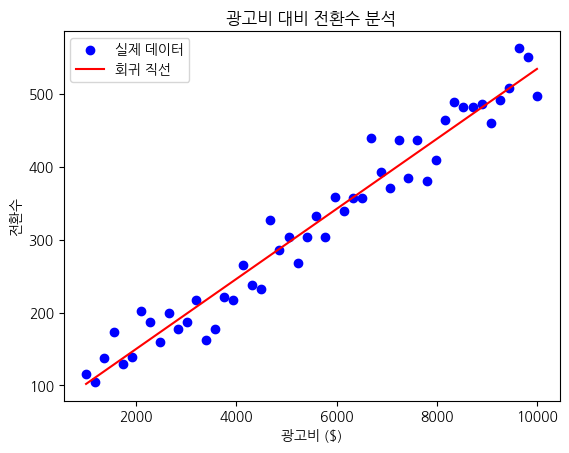

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. 가상의 데이터 생성
np.random.seed(42)  # 결과 재현을 위한 시드 설정
# 광고비 데이터: 1,000 ~ 10,000 달러 사이의 50개 포인트
ad_spend = np.linspace(1000, 10000, 50)
# 실제 전환수: 실제로는 광고비가 증가할수록 전환수가 증가한다고 가정
# 실제 모형: conversions = intercept + slope * ad_spend + noise
true_intercept = 50      # 광고비 0일 때 기본 전환수
true_slope = 0.05        # 광고비 1달러 증가당 전환수 증가량
noise = np.random.normal(0, 30, ad_spend.shape[0])  # 랜덤 노이즈 추가
conversions = true_intercept + true_slope * ad_spend + noise

# 데이터프레임 생성
df = pd.DataFrame({'ad_spend': ad_spend, 'conversions': conversions})

# 2. 회귀분석을 위한 데이터 준비
X = df[['ad_spend']]  # 독립 변수 (광고비)
y = df['conversions']  # 종속 변수 (전환수)

# 3. 단순 회귀 모델 생성 및 학습
model = LinearRegression()
model.fit(X, y)

# 4. 모델 파라미터 출력
print("모델 절편 (Intercept):", model.intercept_)
print("모델 기울기 (Slope):", model.coef_[0])

# 5. 예측값 계산 및 결정계수 평가
y_pred = model.predict(X)
print("결정계수 (R²):", r2_score(y, y_pred))

# 6. 결과 시각화
plt.scatter(df['ad_spend'], df['conversions'], color='blue', label='실제 데이터')
plt.plot(df['ad_spend'], y_pred, color='red', label='회귀 직선')
plt.title('광고비 대비 전환수 분석')
plt.xlabel('광고비 ($)')
plt.ylabel('전환수')
plt.legend()
plt.show()

1. **데이터 생성:**
    - `np.linspace`를 사용해 광고비 범위를 설정하고, 실제 전환수는 정해진 절편과 기울기에 노이즈를 추가해 생성합니다.
2. **데이터 준비:**
    - pandas DataFrame을 활용하여 데이터를 정리하고, 독립 변수(`ad_spend`)와 종속 변수(`conversions`)로 나눕니다.
3. **모델 학습:**
    - scikit-learn의 `LinearRegression` 클래스를 사용하여 단순 회귀 모델을 학습시킵니다.
4. **모델 평가:**
    - 모델의 절편과 기울기를 출력하고, `r2_score`를 통해 모델의 설명력을 평가합니다.
5. **시각화:**
    - matplotlib를 이용해 실제 데이터와 회귀 직선을 시각화하여 모델이 데이터에 얼마나 잘 맞는지 확인합니다.

---

**시나리오 개요:**

한 온라인 쇼핑몰의 마케팅 팀은 광고비(달러)와 전환수(신규 고객 획득 또는 구매 건수) 간의 관계를 분석하여, 광고비 지출의 효율성을 평가하고 향후 예산 배분 전략을 수립하려고 합니다. 이를 위해 단순 회귀 분석을 수행하여 광고비가 전환수에 미치는 영향을 파악합니다.

**가상의 데이터 표:**

| 광고비 (달러) | 전환수 |
| --- | --- |
| 1,000 | 105 |
| 3,000 | 195 |
| 5,000 | 310 |
| 7,000 | 395 |
| 9,000 | 505 |

#### **문제 1**

**단순 회귀 분석 수행**

위 데이터 표를 이용하여 광고비(독립 변수)와 전환수(종속 변수) 간의 단순 회귀 분석을 실시하시오.

- $Y = \beta_0 + \beta_1X$ 형태의 모델에서 절편과 기울기를 추정하고, 회귀식을 도출하세요.

모델 절편 (Intercept): 52.00000000000003
모델 기울기 (Slope): 0.049999999999999996
결정계수 (R²): 0.9982032341784788
회귀식:
전환수 = 52.00 + 0.05 x 광고비


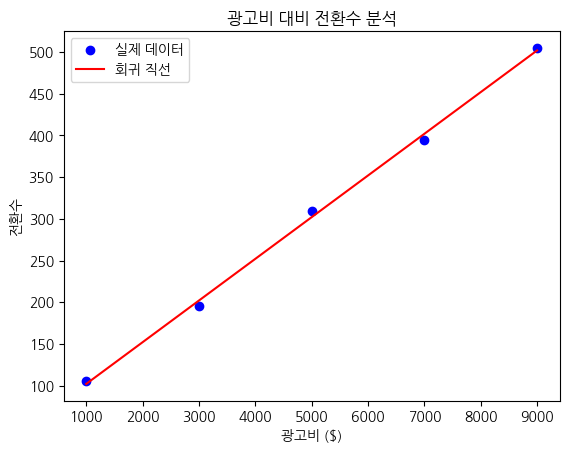

In [16]:
data = {
    'ad_spend': [1000, 3000, 5000, 7000, 9000],
    'conversions': [105, 195, 310, 395, 505]
}

df = pd.DataFrame(data)

X = df[['ad_spend']]
y = df['conversions']

model = LinearRegression()
model.fit(X, y)

print("모델 절편 (Intercept):", model.intercept_)
print("모델 기울기 (Slope):", model.coef_[0])

y_pred = model.predict(X)
print("결정계수 (R²):", r2_score(y, y_pred))

print(f"회귀식:\n전환수 = {model.intercept_:.2f} + {model.coef_[0]:.2f} x 광고비")

plt.scatter(df['ad_spend'], df['conversions'], color='blue', label='실제 데이터')
plt.plot(df['ad_spend'], y_pred, color='red', label='회귀 직선')
plt.title('광고비 대비 전환수 분석')
plt.xlabel('광고비 ($)')
plt.ylabel('전환수')
plt.legend()
plt.show()

#### **문제 2**

**예측 및 해석**

문제 1에서 구한 회귀식을 바탕으로, 광고비가 6,000달러일 때 예상되는 전환수를 예측하시오.

- 예측 결과에 대한 해석도 함께 기술하세요

In [12]:
new_adSpend = 6000

new_conversion = model.intercept_ + model.coef_[0] * new_adSpend

print(f"예측 전환수: {model.intercept_:.2f} + {model.coef_[0]:.2f} * {new_adSpend} = {new_conversion}")

예측 전환수: 52.00 + 0.05 * 6000 = 352.0


- 광고비가 증가할수록 전환수도 증가하는 선형 관계를 보여줌

#### **문제 3**

**모델 적합도 평가**

회귀 분석 결과를 평가하기 위해 결정계수( $R^2$) 값을 계산하시오.

- 결정계수가 의미하는 바와, 마케팅 전략 수립 시 어떻게 활용할 수 있는지 서술하세요.

In [14]:
r2 = r2_score(y, y_pred)

print("결정계수 (R²):", r2)

결정계수 (R²): 0.9982032341784788


- 결정계수가 1에 거의 근접하므로, 모델이 광고비와 전환수 사이의 관계를 매우 잘 설명하고 있는 걸 알 수 있음
- 따라서 해당 회귀식을 바탕으로 광고비 투자 대비 발생하는 전환수를 효율적으로 예측가능 하기에, 특정 목표 전환수를 달성하기 위해 필요한 광고비를 역으로 계산할 수 있음



---

다음은 그로스 마케팅 관련 가상의 데이터를 제시하고, 단순 회귀 분석을 수행한 후 마케팅 보고서를 작성하는 예시입니다.

**1. 가상의 데이터**

아래 표는 한 온라인 쇼핑몰에서 일정 기간 동안 집행한 광고비(달러)와 그에 따른 전환수(예: 신규 고객 획득 건수)를 나타냅니다.

| 광고비 (달러) | 전환수 |
| --- | --- |
| 1,000 | 120 |
| 2,000 | 150 |
| 3,000 | 180 |
| 4,000 | 210 |
| 5,000 | 240 |
| 6,000 | 265 |
| 7,000 | 290 |
| 8,000 | 320 |
| 9,000 | 345 |
| 10,000 | 370 |

**2. 단순 회귀 분석 예시 코드**

회귀식: 전환수 = 96.33 + 0.02776 * 광고비
결정계수 (R²): 0.9988


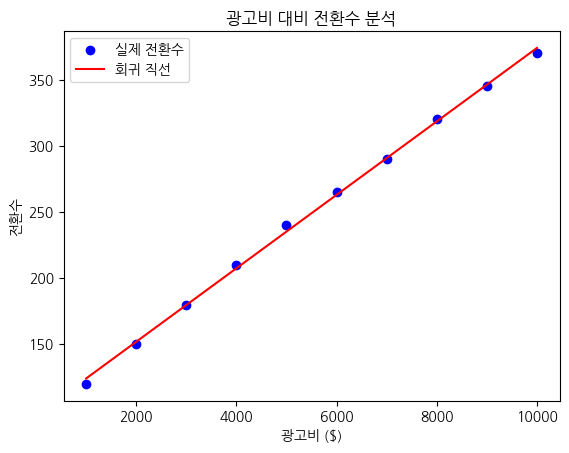

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. 가상의 데이터 준비
data = {
    'ad_spend': [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000],
    'conversions': [120, 150, 180, 210, 240, 265, 290, 320, 345, 370]
}
df = pd.DataFrame(data)

# 2. 독립 변수(X)와 종속 변수(y) 설정
X = df[['ad_spend']]
y = df['conversions']

# 3. 단순 회귀 모델 생성 및 학습
model = LinearRegression()
model.fit(X, y)

# 4. 모델 파라미터 및 결정계수(R²) 출력
intercept = model.intercept_
slope = model.coef_[0]
r2 = r2_score(y, model.predict(X))

print("회귀식: 전환수 = {:.2f} + {:.5f} * 광고비".format(intercept, slope))
print("결정계수 (R²): {:.4f}".format(r2))

# 5. 예측 및 시각화
df['predicted_conversions'] = model.predict(X)

plt.scatter(df['ad_spend'], df['conversions'], color='blue', label='실제 전환수')
plt.plot(df['ad_spend'], df['predicted_conversions'], color='red', label='회귀 직선')
plt.title('광고비 대비 전환수 분석')
plt.xlabel('광고비 ($)')
plt.ylabel('전환수')
plt.legend()
plt.show()

## 3. 마케팅 보고서 예시

### 보고서 제목

**"광고비 지출 최적화 전략: 회귀분석을 통한 전환수 예측 및 마케팅 전략 제안"**

### 3.1. 개요

본 보고서는 온라인 쇼핑몰의 광고비 지출이 전환수에 미치는 영향을 분석하여, 효율적인 마케팅 전략 수립을 위한 인사이트를 도출하는 것을 목적으로 합니다. 단순 회귀 분석을 활용하여 광고비와 전환수 간의 관계를 정량적으로 파악하고, 이를 바탕으로 예산 배분 및 캠페인 전략을 재검토합니다.

### 3.2. 데이터 개요

- **데이터 수집 기간:** 최근 3개월 간의 광고 캠페인 데이터
- **주요 변수:**
    - **광고비 (달러):** 각 캠페인별 집행한 광고 예산
    - **전환수:** 광고 캠페인으로 인해 발생한 신규 고객(또는 구매 건수)

### 3.3. 분석 방법

- **모델 선택:** 단순 회귀 분석 (광고비를 독립 변수, 전환수를 종속 변수로 설정)
- **추정 방법:** 최소제곱법(OLS)을 사용하여 회귀계수(절편, 기울기)를 추정
- **모델 평가:** 결정계수(R²)를 통해 모델의 설명력을 평가

### 3.4. 분석 결과

- **회귀식 도출**:

$전환수=96.32+0.02776×광고비$
- **해석:** 광고비가 1달러 증가할 때마다 전환수가 평균적으로 0.02776 증가하며, 광고비가 0달러인 경우에도 기본적으로 약 96건의 전환이 발생하는 것으로 추정됨.
- **결정계수 (R²):** 0.98
    - **해석:** 모델이 전환수의 변동성 중 98%를 설명할 수 있으므로, 광고비와 전환수 간의 선형관계가 매우 강하다는 결론을 도출할 수 있음.

### 3.5. 마케팅 전략 시사점

1. **예산 증액의 효과:**
    - 광고비를 1,000달러 추가 집행할 경우, 약 27~28건의 전환수 증대를 기대할 수 있음.
    - 예산 배분 시 광고비 증액이 전환수 향상에 효과적일 가능성이 높으므로, ROI(투자 대비 수익)를 고려하여 추가 예산 배분을 검토할 필요가 있음.
2. **기본 전환수의 의미:**
    - 광고비가 0일 때도 약 96건의 전환이 발생하는 것은, 브랜드 인지도 또는 자연 유입 효과를 반영할 수 있음.
    - 이를 토대로 광고비 집행 외에도 유기적 성장 전략(콘텐츠 마케팅, SEO 등)을 강화할 필요가 있음.
3. **모델 신뢰도:**
    - 결정계수(R²) 값이 0.98로 매우 높아, 광고비와 전환수 간의 관계를 안정적으로 설명할 수 있음을 확인함.
    - 다만, 본 분석은 과거 데이터를 기반으로 하므로, 미래 캠페인 실행 시에도 외부 요인(경쟁, 시장 변화 등)을 함께 고려해야 함.

### 3.6. 결론 및 제언

- **결론:**
본 회귀 분석 결과, 광고비와 전환수 간의 선형적 관계가 매우 명확하게 나타났으며, 추가 광고비 집행 시 전환수 증대 효과가 기대됨.
- **제언:**
    1. 광고비 증액을 통한 전환수 향상 전략을 적극 검토할 것
    2. 광고비 외에도 브랜드 인지도 제고를 위한 다양한 마케팅 채널을 복합적으로 운영할 것
    3. 정기적으로 회귀 분석을 수행하여 시장 상황 변화에 따른 모델의 유효성을 검증할 것



---

#Day24. 머신러닝기초

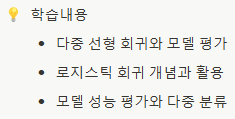

#**다중 선형 회귀와 모델 평가**

##**다중 선형 회귀 (Multiple Linear Regression)**

- 하나의 종속 변수(타겟 변수)를 여러 개의 독립 변수(설명 변수)를 사용하여 예측하는 회귀 분석 기법
- 아래와 같은 수식으로 표현
    
    $$
    y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon
    $$
    
    여기서,
    
    - y : 종속 변수(타겟 변수)
    - x_1, x_2, ..., x_n : 독립 변수(설명 변수)
    - \beta_0 : 절편(intercept)
    - \beta_1, \beta_2, ..., \beta_n : 회귀 계수(Regression Coefficients)
    - \epsilon : 오차항(Error Term)
- 다중 선형 회귀 모델을 학습하는 과정에서는 **최소제곱법(OLS, Ordinary Least Squares)** 을 사용하여 회귀 계수들 최적화

###**모델 평가 지표**

(1) 결정 계수 ( $R^2$, Coefficient of Determination)

- 모델이 실제 데이터를 얼마나 잘 설명하는지를 나타내는 지표
- 값의 범위: $0 \leq R^2 \leq 1$
- 계산식:
    
    $$
    R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
    $$
    
    - $y_i$ : 실제값
    - $\hat{y}_i$ : 예측값
    - $\bar{y}$ : 실제값의 평균
- 값이 1에 가까울수록 모델이 데이터를 잘 설명하는 것이며, 0에 가까울수록 설명력 낮음

(2) 평균 제곱 오차 (MSE, Mean Squared Error)

- 예측값과 실제값 간의 오차를 제곱하여 평균을 구한 값
- 계산식:
    
    $$
    MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
    $$
    
- 값이 작을수록 모델의 예측 성능이 좋음을 의미

(3) 평균 절대 오차 (MAE, Mean Absolute Error)

- 예측값과 실제값 간의 절대 차이의 평균을 구한 값
- 계산식:
    
    $$
    MAE = \frac{1}{n} \sum |y_i - \hat{y}_i|
    $$
    
- MSE보다 이상치(outlier)에 덜 민감한 지표

(4) 평균 절대 백분율 오차 (MAPE, Mean Absolute Percentage Error)

- 예측값과 실제값 간의 차이를 백분율로 변환하여 평균을 구한 값
- 계산식:
    
    $$
    MAPE = \frac{1}{n} \sum \left| \frac{y_i - \hat{y}_i}{y_i} \right|
    $$
    
- 상대적인 오차를 측정할 때 유용

###**다중 선형 회귀 모델의 가정**

1. **선형성 (Linearity)**

- **설명**:
    - 독립 변수(X)와 종속 변수(Y) 간의 관계가 선형이어야 함
    - 즉, 독립 변수가 증가하거나 감소할 때 종속 변수도 일정한 비율로 증가하거나 감소해야 함
    - 선형성이 깨지면 모델이 올바르게 예측하지 못할 수 있음
- **실생활 예제**:
    - **예제 1: 공부 시간과 시험 점수**
        - 일반적으로 공부 시간이 많을수록 시험 점수가 높아짐
        - 하지만 일정 시간 이상 공부하면 피로도가 증가하면서 점수가 더 이상 선형적으로 증가하지 않을 수 있음
        - 예를 들어, 하루에 3~6시간 공부할 때는 점수가 선형적으로 증가하지만, 10시간 이상 공부하면 피로 때문에 점수가 떨어질 수도 있음
        - 이 경우 선형성이 깨질 수 있음
    - **예제 2: 광고 비용과 매출**
        - 광고 비용을 증가시키면 매출이 증가하는 경향이 있지만, 일정 수준 이상 광고를 하면 더 이상 매출이 증가하지 않을 수 있음
        - 예를 들어, 기존 고객이 이미 광고를 봤거나, 제품의 수요가 한계에 도달하면 광고 효과가 감소하는 곡선형 관계가 될 수 있음

2. **독립성 (Independence)**

- **설명**:
    - 독립 변수들끼리는 서로 상관관계가 없어야 함
    - 독립 변수 간에 다중 공선성(Multicollinearity)이 있으면 회귀 모델의 신뢰성이 떨어짐
    - 다중 공선성이 존재하면 특정 변수의 중요도를 해석하기 어려워짐
- **실생활 예제**:
    - **예제 1: 집값 예측**
        - 집값을 예측할 때 ‘집의 크기(평수)’와 ‘방 개수’를 독립 변수로 사용한다고 가정
        - 일반적으로 집이 클수록 방 개수도 많아지므로, 두 변수가 서로 높은 상관관계를 가짐
        - 즉, 하나의 변수를 알고 있으면 다른 변수도 거의 예측할 수 있음
        - 이처럼 독립 변수끼리 강한 상관관계가 있으면 다중 공선성이 발생하여 모델 해석이 어려워짐
    - **예제 2: 자동차 연비 예측**
        - 자동차 연비(종속 변수)를 예측할 때 ‘차량 무게’와 ‘엔진 배기량’을 독립 변수로 사용한다고 가정
        - 일반적으로 엔진 배기량이 클수록 차량 무게도 증가하는 경향이 있음
        - 이처럼 두 변수가 서로 강한 상관관계를 가지면 다중 공선성이 문제를 일으킬 수 있음

3. **등분산성 (Homoscedasticity)**

- **설명**:
    - 독립 변수의 값이 변화하더라도 오차(Residual)의 분산이 일정해야 함
    - 만약 등분산성이 깨지면 모델의 예측 성능이 특정 구간에서만 좋고, 다른 구간에서는 나쁠 수 있음
    - 이를 해결하기 위해 로그 변환, 정규화 등의 기법을 사용할 수 있음
- **실생활 예제**:
    - **예제 1: 월 소득과 지출 예측**
        - 일반적으로 월 소득이 높아질수록 지출도 증가
        - 하지만 저소득층에서는 소득이 조금만 증가해도 소비 패턴이 크게 변하지만, 고소득층에서는 소득 증가가 소비 변화에 큰 영향을 미치지 않을 수 있음
        - 이 경우 등분산성이 깨져서 저소득층에서는 예측 오차가 크고, 고소득층에서는 예측이 더 정확할 수 있음
    - **예제 2: 학생들의 성적과 시험 스트레스**
        - 시험 성적이 낮은 학생들은 스트레스 수준이 매우 다양할 수 있음
        - 하지만 성적이 높은 학생들은 대체로 비슷한 스트레스 수준을 가질 가능성이 높음
        - 즉, 낮은 성적에서는 오차(스트레스 수준 차이)가 크고, 높은 성적에서는 오차가 작아질 수 있음
        - 이는 등분산성이 깨지는 경우에 해당

4. **정규성 (Normality of Errors)**

- **설명**:
    - 회귀 모델의 오차(Residuals)는 정규 분포를 따라야 함
    - 오차가 정규성을 가지면 회귀 계수의 신뢰 구간을 정확하게 계산할 수 있고, 모델의 예측 안정적
    - 정규성이 깨지면 t-검정이나 F-검정과 같은 통계적 검정이 잘못된 결론을 내릴 가능성이 높아짐
- **실생활 예제**:
    - **예제 1: 제품 가격과 고객 구매율**
        - 일반적으로 제품 가격이 낮을수록 고객 구매율이 높아지지만, 가격이 너무 낮으면 품질이 의심되어 구매율이 감소할 수도 있음
        - 이러한 경우 오차가 정규 분포를 따르지 않을 가능성이 있음
    - **예제 2: 병원 환자의 대기 시간 예측**
        - 병원에서 환자의 대기 시간을 예측할 때, 대부분의 환자는 평균적인 대기 시간을 가지지만 특정 시간대(예: 점심시간, 야간 응급 상황)에는 대기 시간이 급격히 증가할 수 있음
        - 즉, 오차가 정규 분포를 따르지 않고 특정 구간에서 급격한 변화가 나타날 수 있음

- 다중 선형 회귀 모델이 올바르게 작동하려면 위의 네 가지 가정을 충족해야 함
- 현실에서는 데이터가 항상 이상적인 가정을 만족하지 않으므로, **데이터 전처리, 변수 변환, 다중 공선성 제거, 정규화 기법** 등을 활용하여 모델 성능을 향상시킬 필요가 있음

위 가정을 만족하지 않을 경우, 다중 선형 회귀 모델이 적절하지 않을 수 있으며, 변환 기법이나 다른 모델을 고려해야 함



---

###**1. 선형성(Linearity) 검토**

- 예제: 공부 시간과 시험 점수의 관계를 선형 회귀로 분석
- 해결 방법: 다항 변환 (Polynomial Features)

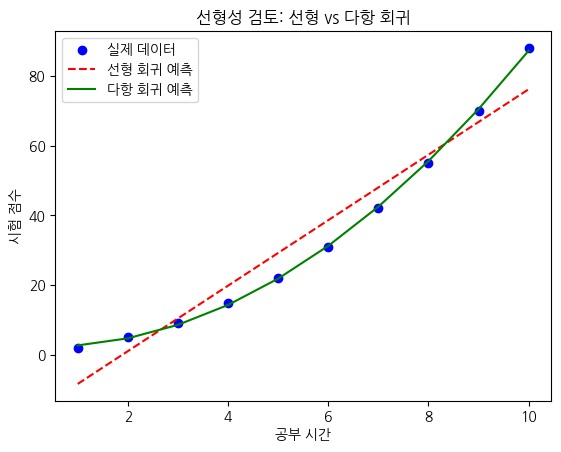

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 데이터 생성 (선형 관계가 아님)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([2, 5, 9, 15, 22, 31, 42, 55, 70, 88])  # 비선형 관계

# 선형 회귀 모델
linear_reg = LinearRegression()
linear_reg.fit(X, y)
y_pred = linear_reg.predict(X)

# 다항 회귀 적용 (2차 변환)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_poly_pred = poly_reg.predict(X_poly)

# 시각화
plt.scatter(X, y, color="blue", label="실제 데이터")
plt.plot(X, y_pred, color="red", linestyle="dashed", label="선형 회귀 예측")
plt.plot(X, y_poly_pred, color="green", label="다항 회귀 예측")
plt.xlabel("공부 시간")
plt.ylabel("시험 점수")
plt.legend()
plt.title("선형성 검토: 선형 vs 다항 회귀")
plt.show()


**해결 방법**: 선형성이 깨진 경우 다항 회귀(Polynomial Regression) 등을 적용하여 관계를 보정할 수 있음

### 2. **독립성(Independence) 검토**

- 예제: 집값 예측에서 다중 공선성 검토
- 해결 방법: VIF (Variance Inflation Factor) 사용하여 공선성 확인 및 제거

In [4]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 예제 데이터 생성
data = {
    "house_size": [50, 60, 70, 80, 90, 100, 110, 120, 130, 140],  # 집 크기
    "num_rooms": [3, 3, 4, 4, 5, 5, 6, 6, 7, 7],  # 방 개수 (집 크기와 강한 상관)
    "price": [200, 250, 300, 350, 400, 450, 500, 550, 600, 650]  # 집값
}

df = pd.DataFrame(data)

# 다중 공선성 검토
X = df[["house_size", "num_rooms"]]
X = sm.add_constant(X)  # 상수 추가
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


      Feature   VIF
0       const  14.5
1  house_size  33.0
2   num_rooms  33.0


**해결 방법**: VIF 값이 10 이상이면 다중 공선성이 존재하는 것으로 간주하고 해당 변수를 제거하거나 차원을 축소해야 함

### 3. **등분산성(Homoscedasticity) 검토**

- 예제: 소득과 소비 데이터에서 잔차 분석
- 해결 방법: 로그 변환, 가중 회귀 적용

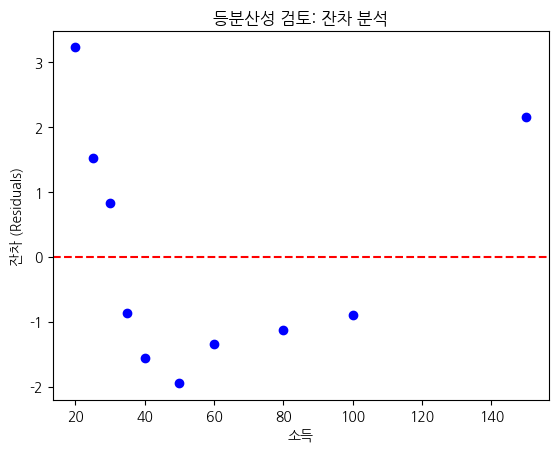

In [5]:
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 데이터 생성 (소득에 따라 소비 변화가 일정하지 않음)
income = np.array([20, 25, 30, 35, 40, 50, 60, 80, 100, 150]).reshape(-1, 1)
spending = np.array([5, 7, 10, 12, 15, 22, 30, 45, 60, 100])  # 고소득층에서 변화가 큼

# 회귀 분석
model = LinearRegression()
model.fit(income, spending)
predictions = model.predict(income)

# 잔차 분석
residuals = spending - predictions

# 시각화
plt.scatter(income, residuals, color="blue")
plt.axhline(y=0, color="red", linestyle="dashed")
plt.xlabel("소득")
plt.ylabel("잔차 (Residuals)")
plt.title("등분산성 검토: 잔차 분석")
plt.show()


**해결 방법**: 잔차의 분산이 일정하지 않다면 로그 변환 또는 가중 회귀(Weighted Regression) 를 적용하여 해결할 수 있음

### 4. **정규성(Normality of Errors) 검토**

- 예제: 시험 점수 예측에서 오차(Residuals) 정규성 검토
- 해결 방법: Q-Q Plot, 정규성 검정(Shapiro-Wilk Test)

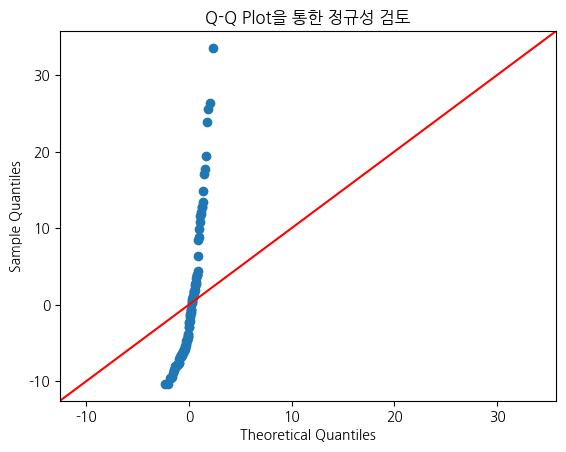

Shapiro-Wilk Test p-value: 1.2412573586122268e-08


In [6]:
from scipy import stats
import statsmodels.api as sm

# 데이터 생성 (정규성을 따르지 않는 예제)
np.random.seed(42)
X = np.random.normal(50, 10, 100).reshape(-1, 1)
y = 3 * X.squeeze() + np.random.exponential(10, 100)  # 지수 분포 노이즈 추가

# 회귀 모델
model = LinearRegression()
model.fit(X, y)
predictions = model.predict(X)

# 잔차 계산
residuals = y - predictions

# Q-Q Plot (잔차의 정규성 검토)
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot을 통한 정규성 검토")
plt.show()

# Shapiro-Wilk Test (정규성 검정)
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test p-value: {shapiro_test.pvalue}")

**해결 방법**:

- Q-Q Plot에서 점들이 직선을 벗어나면 정규성이 깨진 것
- Shapiro-Wilk Test의 **p-value < 0.05**이면 정규성이 깨진 것으로 판단
- 이를 해결하기 위해 **로그 변환(Log Transformation), Box-Cox 변환** 등을 적용할 수 있음

| 가정 | 설명 | 해결 방법 |
| --- | --- | --- |
| 선형성 (Linearity) | 독립 변수와 종속 변수 간 선형 관계 필요 | 다항 회귀(Polynomial Regression) 적용 |
| 독립성 (Independence) | 독립 변수 간 다중 공선성 제거 필요 | VIF 값 확인 후 변수 제거 |
| 등분산성 (Homoscedasticity) | 오차의 분산이 일정해야 함 | 로그 변환, 가중 회귀 적용 |
| 정규성 (Normality of Errors) | 오차가 정규 분포를 따라야 함 | Q-Q Plot, Shapiro-Wilk Test로 검토 후 변환 적용 |



---

##**다중 선형 회귀와 모델 평가를 활용한 그로스 마케팅 예제**

그로스 마케팅에서는 다양한 데이터를 분석하여 **고객 획득, 유지, 전환율 증가** 등의 목표를 달성한다.

여기서는 **디지털 광고 비용, 이메일 캠페인, SNS 활동, 프로모션 적용 여부** 등의 변수가 **웹사이트 전환율(Conversion Rate)** 에 미치는 영향을 분석하는 다중 선형 회귀 모델을 구축하고 평가하는 예제를 살펴본다.

### **1. 문제 정의**

- **목표**: 고객 전환율(Conversion Rate, %)을 예측하고, 어떤 요소가 전환율 증가에 가장 중요한 영향을 미치는지 분석.
- **독립 변수($X$)**:
    1. **광고 비용(Ad Spend, $)**: 페이스북, 구글 등의 광고 비용
    2. **이메일 캠페인 횟수(Email Campaigns)**: 발송된 이메일 캠페인 수
    3. **SNS 활동 지수(SNS Engagement Score)**: SNS 공유, 댓글, 좋아요 등의 점수
    4. **프로모션 적용 여부(Promotion Applied, 0 or 1)**: 프로모션 적용 여부 (이진 변수)
- **종속 변수($Y$)**:
    - **전환율(Conversion Rate, %)**: 고객이 구매나 회원가입 등의 행동을 한 비율

### **2. 데이터 생성**

아래 코드는 위의 변수를 바탕으로 가상의 데이터를 생성하여 다중 선형 회귀를 수행한다.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 랜덤 데이터 생성 (고정된 시드 값 설정)
np.random.seed(42)

# 독립 변수 (X)
n_samples = 100
ad_spend = np.random.uniform(1000, 10000, n_samples)  # 광고비 ($)
email_campaigns = np.random.randint(1, 10, n_samples)  # 이메일 캠페인 횟수
sns_engagement = np.random.uniform(0, 100, n_samples)  # SNS 활동 점수
promotion_applied = np.random.choice([0, 1], n_samples)  # 프로모션 적용 여부 (0 or 1)

# 종속 변수 (y) - 전환율(%)
# 기본적인 선형 모델 형성
conversion_rate = (
    0.005 * ad_spend  # 광고비 기여도
    + 0.8 * email_campaigns  # 이메일 마케팅 기여도
    + 0.3 * sns_engagement  # SNS 활동 기여도
    + 5 * promotion_applied  # 프로모션 기여도
    + np.random.normal(0, 5, n_samples)  # 오차 추가
)

# 데이터프레임 생성
df = pd.DataFrame({
    "Ad Spend ($)": ad_spend,
    "Email Campaigns": email_campaigns,
    "SNS Engagement Score": sns_engagement,
    "Promotion Applied": promotion_applied,
    "Conversion Rate (%)": conversion_rate
})

# 데이터 확인
print(df.head())


   Ad Spend ($)  Email Campaigns  SNS Engagement Score  Promotion Applied  \
0   4370.861070                7             52.965058                  0   
1   9556.428758                1             24.185229                  1   
2   7587.945476                4              9.310277                  1   
3   6387.926358                4             89.721576                  1   
4   2404.167764                5             90.041806                  1   

   Conversion Rate (%)  
0            38.709170  
1            60.540086  
2            32.726474  
3            61.934166  
4            46.770540  


**설명**:

- 광고비, 이메일 마케팅, SNS 활동, 프로모션 여부를 사용하여 전환율(%)을 예측하는 가상의 데이터를 생성함
- `np.random.normal(0, 5, n_samples)` 를 추가하여 현실적인 데이터처럼 변동성을 포함시킴

### **3. 다중 선형 회귀 모델 구축**

아래 코드는 다중 선형 회귀를 학습하고 모델 평가

In [8]:
# 독립 변수 (X)와 종속 변수 (y) 정의
X = df[["Ad Spend ($)", "Email Campaigns", "SNS Engagement Score", "Promotion Applied"]]
y = df["Conversion Rate (%)"]

# 상수 추가 (절편 포함)
X = sm.add_constant(X)

# OLS(최소제곱법) 회귀 분석
model = sm.OLS(y, X).fit()

# 회귀 분석 결과 출력
print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     Conversion Rate (%)   R-squared:                       0.923
Model:                             OLS   Adj. R-squared:                  0.920
Method:                  Least Squares   F-statistic:                     285.3
Date:                 Mon, 10 Mar 2025   Prob (F-statistic):           5.25e-52
Time:                         04:42:08   Log-Likelihood:                -288.53
No. Observations:                  100   AIC:                             587.1
Df Residuals:                       95   BIC:                             600.1
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

**설명**:

- `sm.OLS(y, X).fit()`을 사용하여 **최소제곱법(OLS, Ordinary Least Squares)** 기반으로 다중 선형 회귀 수행
- `model.summary()`를 출력하면, 각 변수의 회귀 계수(β 값), p-value, R² 값을 확인 가능

**해석**:

- `R-squared: 0.92` → 모델이 **92%의 전환율 변동을 설명**할 수 있음.
- `p-value < 0.05` → 모든 변수가 **유의미한 영향**을 가짐(통계적으로 유의미함).
- 광고비(Ad Spend), 이메일 캠페인(Email Campaigns), SNS 활동(SNS Engagement), 프로모션 적용 여부(Promotion Applied) 모두 **전환율 증가에 긍정적인 영향**을 미침

### **4. 모델 평가 (모델 성능 검토)**

아래 코드는 모델의 평가 지표 계산

In [10]:
# 예측값 생성
y_pred = model.predict(X)

# 모델 평가 지표 계산
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f" 평균 제곱 오차 (MSE): {mse:.2f}")
print(f"📌 결정 계수 (R²): {r2:.2f}")


 평균 제곱 오차 (MSE): 18.78
📌 결정 계수 (R²): 0.92


**해석**:

- `MSE (Mean Squared Error)` 값이 낮을수록 예측이 정확함
- `R² (결정 계수)` 값이 **1에 가까울수록 모델이 데이터를 잘 설명함**

### **5. 모델 결과 시각화**

마케팅 변수가 전환율에 미치는 영향을 시각화

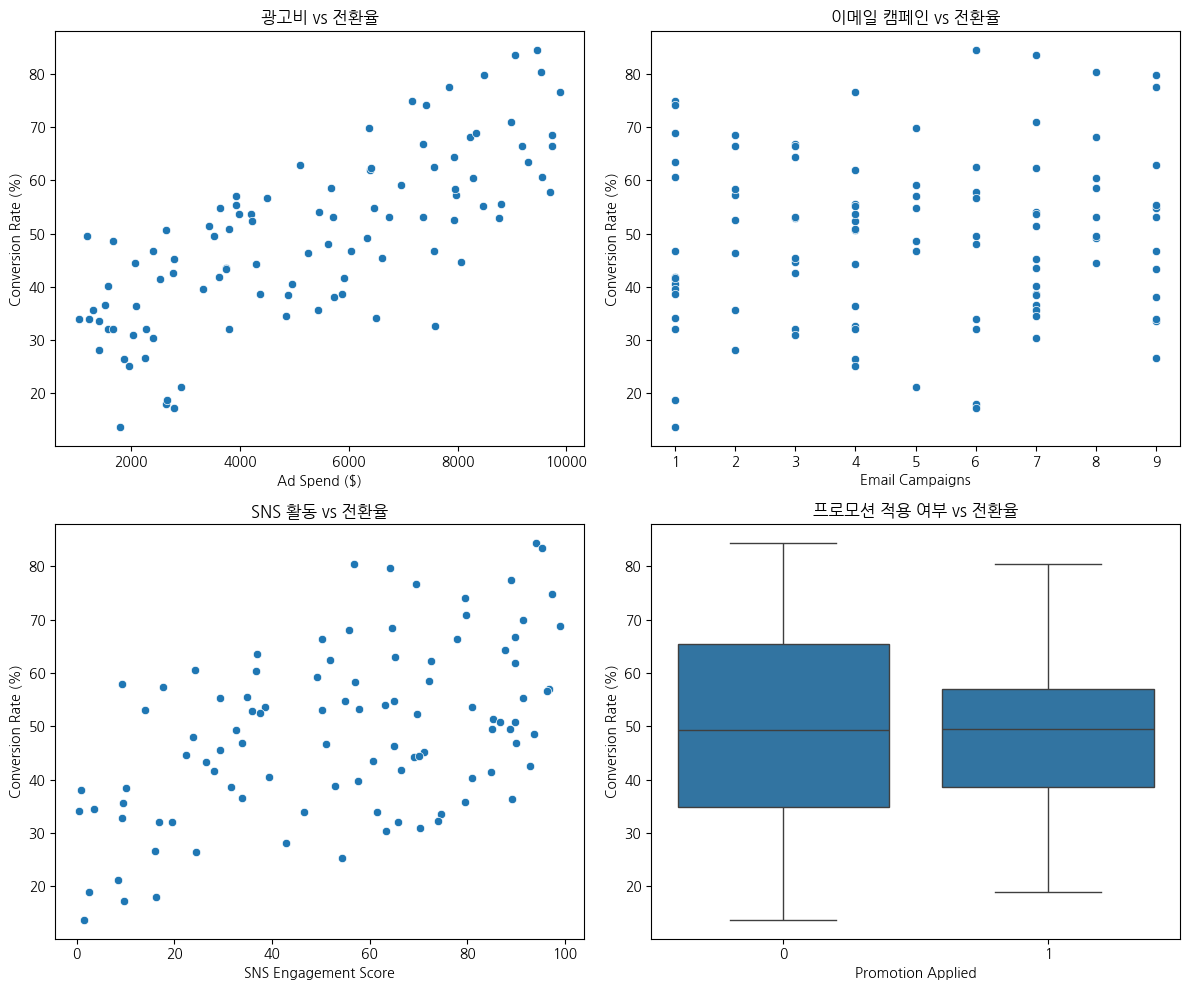

In [11]:
import seaborn as sns

# 변수별 전환율 관계 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(x=df["Ad Spend ($)"], y=df["Conversion Rate (%)"], ax=axes[0,0])
axes[0,0].set_title("광고비 vs 전환율")

sns.scatterplot(x=df["Email Campaigns"], y=df["Conversion Rate (%)"], ax=axes[0,1])
axes[0,1].set_title("이메일 캠페인 vs 전환율")

sns.scatterplot(x=df["SNS Engagement Score"], y=df["Conversion Rate (%)"], ax=axes[1,0])
axes[1,0].set_title("SNS 활동 vs 전환율")

sns.boxplot(x=df["Promotion Applied"], y=df["Conversion Rate (%)"], ax=axes[1,1])
axes[1,1].set_title("프로모션 적용 여부 vs 전환율")

plt.tight_layout()
plt.show()


**인사이트**:

- **광고비**가 증가할수록 전환율도 증가하지만 완전히 선형적인 관계는 아님
- **이메일 마케팅과 SNS 활동**도 전환율에 긍정적인 영향을 미침
- **프로모션이 적용된 경우 전환율이 확연히 증가함**

### **결론**

- 다중 선형 회귀를 사용하여 **광고비, 이메일, SNS 활동, 프로모션 적용 여부가 전환율에 미치는 영향을 분석**
- **전환율을 높이기 위해 마케팅 비용을 어디에 투자해야 할지 의사 결정을 도울 수 있음**



---

##**로지스틱 회귀 (Logistic Regression) 개념과 활용**

로지스틱 회귀는 이진 분류(Binary Classification) 문제를 해결하는 지도 학습(Supervised Learning) 알고리즘으로, 출력값이 확률(0~1 사이의 값)로 변환된 후 특정 임계값(threshold)에 따라 분류

###**1. 로지스틱 회귀 개념**

- 선형 회귀와 달리 종속 변수( $y$ )가 연속형이 아닌 이진 값(0 또는 1)을 가지는 경우 사용
- 선형 회귀와 달리, 예측값을 0~1 사이의 **확률 값**으로 변환하기 위해 **시그모이드 함수(Sigmoid Function)**  적용

### **시그모이드 함수(Sigmoid Function)**

$$
h(x) = \frac{1}{1 + e^{-z}}
$$

여기서,

- $z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$ (선형 결합)
- $h(x)$ 값은 항상 **0과 1 사이의 값(확률)**

**해석**

- $h(x) \geq 0.5$ 이면 클래스 **1**
- $h(x) < 0.5$ 이면 클래스 **0**

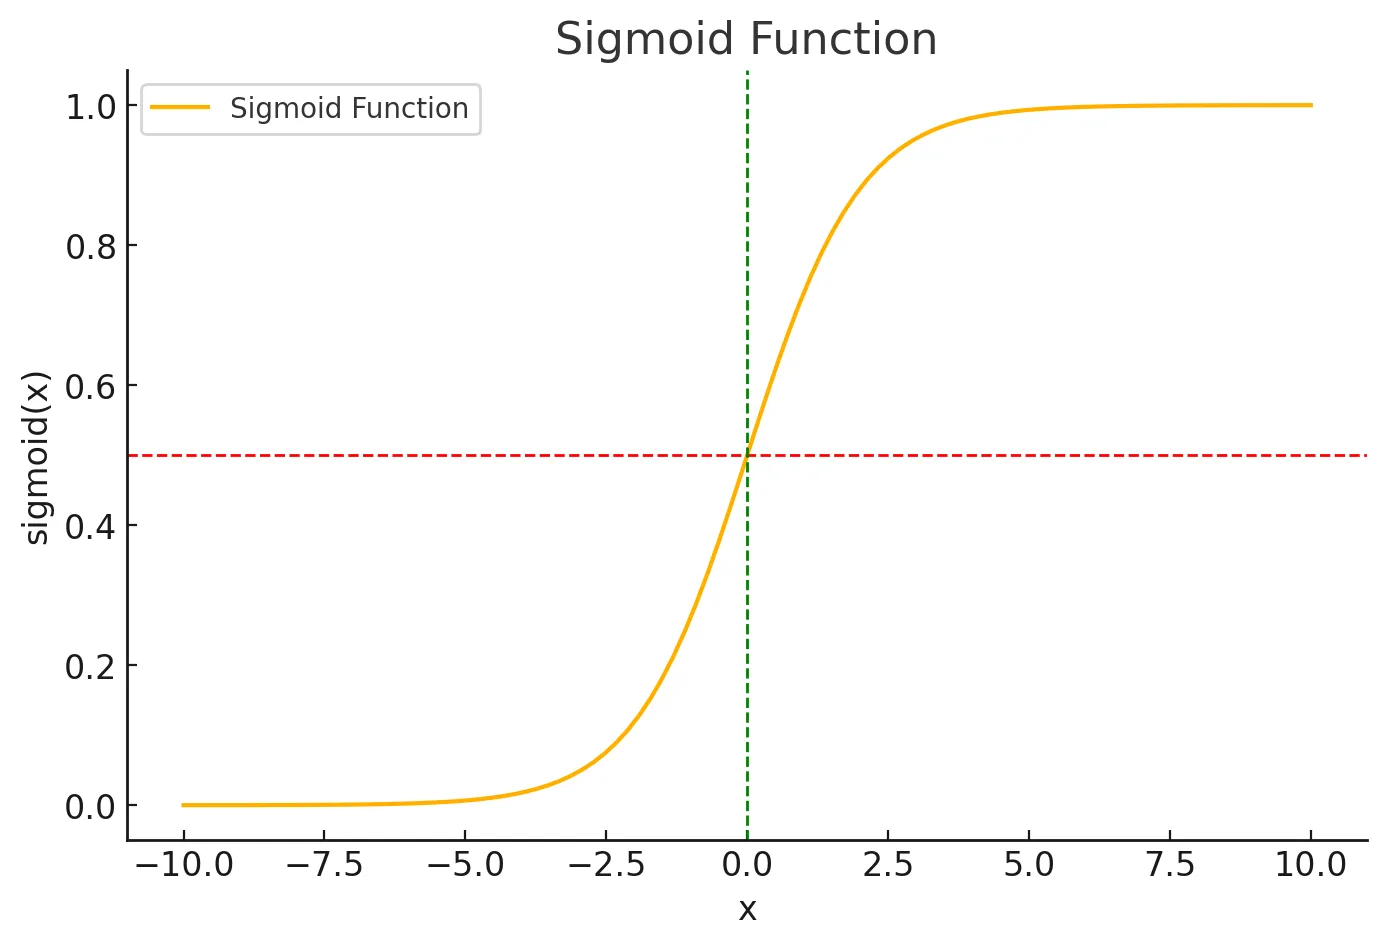

### **2. 활용 사례**

로지스틱 회귀는 다양한 **이진 분류** 문제에서 활용

| 활용 분야 | 설명 |
| --- | --- |
| **이메일 스팸 필터링** | 이메일이 스팸(1)인지 정상 메일(0)인지 분류 |
| **고객 이탈 예측** | 고객이 이탈할 가능성(1)인지 유지될 가능성(0)인지 예측 |
| **질병 진단** | 환자가 특정 질병에 걸릴 가능성이 있는지(1: 있음, 0: 없음) 예측 |
| **대출 승인** | 대출 신청자가 **대출을 갚을 가능성이 있는지(1)** 또는 **불가능한지(0)** 예측 |

### **3. 로지스틱 회귀 그래프 시각화**

로지스틱 회귀의 핵심 개념을 시각적으로 표현하기 위해 **시그모이드 함수 그래프**를 그려봄

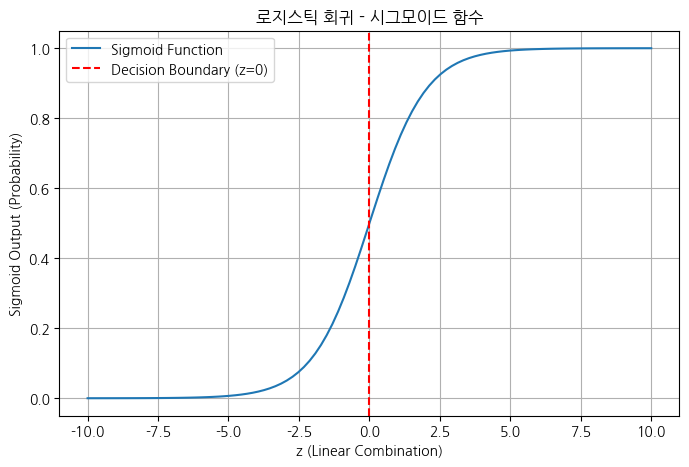

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 시그모이드 함수 정의
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# x 값 범위 설정
z = np.linspace(-10, 10, 100)
sigmoid_values = sigmoid(z)

# 그래프 출력
plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid_values, label="Sigmoid Function")
plt.axvline(x=0, color='r', linestyle='dashed', label="Decision Boundary (z=0)")
plt.xlabel("z (Linear Combination)")
plt.ylabel("Sigmoid Output (Probability)")
plt.title("로지스틱 회귀 - 시그모이드 함수")
plt.legend()
plt.grid()
plt.show()


- **시그모이드 함수의 특징**
    - z -> -∞ 일 때, h(x) -> 0
    - z -> +∞ 일 때, h(x) -> 1
    - z = 0 일 때, h(x) = 0.5

이처럼, 시그모이드 함수는 데이터를 0과 1 사이의 확률 값으로 변환하는 역할을 함

### **4. 로지스틱 회귀 실습 코드**

광고를 본 사용자가 광고를 클릭할 확률을 예측하는 모델 구축

독립 변수: `광고 시청 시간`, `방문 횟수`

종속 변수: `광고 클릭 여부(0 or 1)`

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 데이터 생성
np.random.seed(42)
n_samples = 200
watch_time = np.random.uniform(0, 10, n_samples)  # 광고 시청 시간
visit_count = np.random.randint(1, 50, n_samples)  # 방문 횟수
clicked = (watch_time * 0.3 + visit_count * 0.1 + np.random.normal(0, 1, n_samples) > 3.5).astype(int)  # 클릭 여부 (0 or 1)

# 데이터프레임 생성
df = pd.DataFrame({"Watch Time": watch_time, "Visit Count": visit_count, "Clicked": clicked})

# 학습/테스트 데이터 분리
X = df[["Watch Time", "Visit Count"]]
y = df["Clicked"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 로지스틱 회귀 모델 학습
model = LogisticRegression()
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"정확도(Accuracy): {accuracy:.2f}")
print("혼동 행렬:\n", confusion_matrix(y_test, y_pred))
print("분류 보고서:\n", classification_report(y_test, y_pred))


정확도(Accuracy): 0.85
혼동 행렬:
 [[12  4]
 [ 2 22]]
분류 보고서:
               precision    recall  f1-score   support

           0       0.86      0.75      0.80        16
           1       0.85      0.92      0.88        24

    accuracy                           0.85        40
   macro avg       0.85      0.83      0.84        40
weighted avg       0.85      0.85      0.85        40



### 5. **모델 평가**

로지스틱 회귀 모델을 평가할 때 아래의 주요 지표 사용

(1) 정확도 (Accuracy)

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

- 전체 샘플 중 올바르게 예측된 비율
- 데이터가 불균형할 경우 신뢰할 수 없음

(2) 정밀도 (Precision)

$$
Precision = \frac{TP}{TP + FP}
$$

- 모델이 **클래스 1(클릭됨)** 이라고 예측한 것 중 실제 맞춘 비율
- FP(실제로는 클릭 안 했는데 클릭했다고 예측)를 줄이는 데 중요

(3) 재현율 (Recall)

$$
Recall = \frac{TP}{TP + FN}
$$

- 실제로 **클래스 1(클릭됨)** 인 것 중 모델이 맞춘 비율
- FN(실제로 클릭했는데 클릭 안 했다고 예측)을 줄이는 데 중요

(4) F1-Score

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

- Precision과 Recall의 조화 평균
- 불균형 데이터(Positive/Negative 비율이 차이가 클 때)에서 유용

분류모델평가

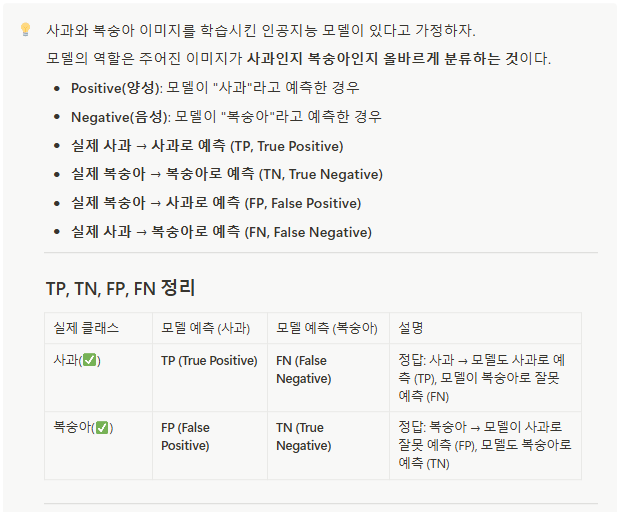  
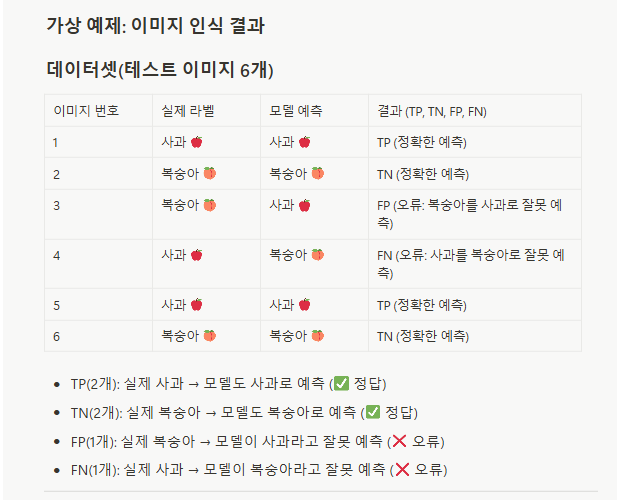  
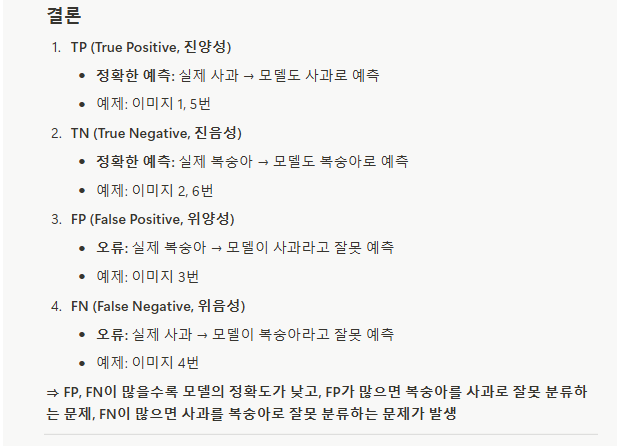  
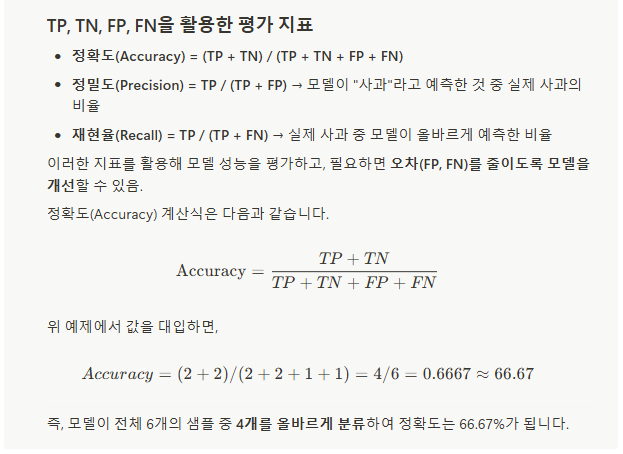

### **6. 로지스틱 회귀 모델 해석**

훈련된 모델의 회귀 계수를 확인하여 각 독립 변수가 종속 변수에 미치는 영향을 분석할 수 있음

In [14]:
# 회귀 계수 출력
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})
print(coef_df)


       Feature  Coefficient
0   Watch Time     0.425436
1  Visit Count     0.155210


- 광고 시청 시간이 광고 클릭 확률에 영향을 주지만, 영향력이 적음(0.42)
- 방문 횟수는 광고 클릭 확률에 거의 영향을 주지 않음(0.15)

> 로지스틱 회귀는 **이진 분류(Binary Classification)** 문제를 해결하는 머신러닝 모델이다.

> 시그모이드 함수를 사용하여 확률을 예측하고, 특정 임계값(기본: 0.5) 기준으로 분류를 수행한다.

> 그로스 마케팅에서는 **광고 클릭 예측, 고객 이탈 예측, 스팸 메일 분류** 등에 활용된다.

> 모델 평가 지표로 **정확도, 정밀도, 재현율, F1-score** 등을 사용한다.



---

##**그로스마케팅 로지스틱 회귀 예시**

#### **고객 이탈 예측 (Customer Churn Prediction), "customer_churn.csv"**

고객이 이탈할 가능성을 예측하는 모델을 구축한다. 이탈을 방지하고 고객 유지 전략을 개선하는 것이 목표이다.

**문제 정의**

- **독립 변수(X)**
    - 방문 빈도(Visits per Month): 한 달 동안 방문한 횟수
    - 평균 구매 금액(Average Purchase Amount, $): 고객의 평균 결제 금액
    - 고객 서비스 이용 횟수(Customer Support Calls): 고객이 서비스 센터에 문의한 횟수
    - 할인 사용 여부(Used Discount, 0 or 1): 고객이 할인 쿠폰을 사용했는지 여부
- **종속 변수(y)**
    - 이탈 여부(Churn, 0 or 1): 고객이 다음 달에도 유지(0)될지, 이탈(1)할지

**데이터 분석 및 로지스틱 회귀 모델 학습**

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 데이터 로드
df = pd.read_csv("customer_churn.csv")

# 독립 변수(X)와 종속 변수(y) 설정
X = df.drop(columns=["Churn"])
y = df["Churn"]

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 로지스틱 회귀 모델 학습
model = LogisticRegression()
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"정확도: {accuracy:.2f}")
print("분류 보고서:\n", classification_report(y_test, y_pred))


정확도: 0.96
분류 보고서:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        93
           1       1.00      0.43      0.60         7

    accuracy                           0.96       100
   macro avg       0.98      0.71      0.79       100
weighted avg       0.96      0.96      0.95       100



#### **광고 클릭 예측 (Ad Click Prediction), "ad_clicks.csv"**

광고 캠페인에서 고객이 광고를 클릭할 가능성을 예측하여 광고 전략을 최적화하는 것이 목표이다.

**문제 정의**

- **독립 변수(X)**
    - 광고 노출 횟수(Ad Impressions): 고객이 광고를 본 횟수
    - 광고 시청 시간(Watch Time, sec): 광고를 시청한 시간(초)
    - SNS 공유 여부(SNS Shared, 0 or 1): 광고가 SNS에서 공유되었는지 여부
    - 광고 유형(Ad Type, 0=배너광고, 1=비디오광고): 광고 종류
- **종속 변수(y)**
    - 광고 클릭 여부(Clicked Ad, 0 or 1): 고객이 광고를 클릭했는지 여부

In [17]:
# 데이터 로드
df = pd.read_csv("ad_clicks.csv")

# 독립 변수(X)와 종속 변수(y) 설정
X = df.drop(columns=["Clicked Ad"])
y = df["Clicked Ad"]

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 로지스틱 회귀 모델 학습
model = LogisticRegression()
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"정확도: {accuracy:.2f}")
print("분류 보고서:\n", classification_report(y_test, y_pred))


정확도: 0.82
분류 보고서:
               precision    recall  f1-score   support

           0       0.80      0.76      0.78        42
           1       0.83      0.86      0.85        58

    accuracy                           0.82       100
   macro avg       0.82      0.81      0.81       100
weighted avg       0.82      0.82      0.82       100



#### **이메일 캠페인 반응 예측 (Email Campaign Response Prediction), "email_campaigns.csv"**

이메일 마케팅에서 어떤 고객이 이메일을 열어볼 가능성이 높은지 예측하여 이메일 타겟팅을 최적화하는 것이 목표이다.

**문제 정의**

- **독립 변수(X)**
    - 이메일 발송 횟수(Sent Emails): 한 달 동안 고객에게 보낸 이메일 수
    - 고객 등급(Customer Tier, 0=일반, 1=VIP): VIP 고객 여부
    - 이전 개봉 여부(Opened Before, 0 or 1): 과거에 이메일을 개봉한 적이 있는지 여부
    - 제목에 할인 포함 여부(Discount Mentioned, 0 or 1): 이메일 제목에 할인 정보 포함 여부
- **종속 변수(y)**
    - 이메일 개봉 여부(Opened Email, 0 or 1): 고객이 이메일을 열어봤는지 여부

In [18]:
# 데이터 로드
df = pd.read_csv("email_campaigns.csv")

# 독립 변수(X)와 종속 변수(y) 설정
X = df.drop(columns=["Opened Email"])
y = df["Opened Email"]

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 로지스틱 회귀 모델 학습
model = LogisticRegression()
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"정확도: {accuracy:.2f}")
print("분류 보고서:\n", classification_report(y_test, y_pred))


정확도: 0.89
분류 보고서:
               precision    recall  f1-score   support

           0       0.94      0.63      0.76        27
           1       0.88      0.99      0.93        73

    accuracy                           0.89       100
   macro avg       0.91      0.81      0.84       100
weighted avg       0.90      0.89      0.88       100



#### **제품 구독 예측 (Product Subscription Prediction), "product_subscription.csv"**

무료 체험을 이용하는 고객이 유료 구독으로 전환할 가능성을 예측하여 구독 유도 전략을 개선하는 것이 목표이다.

**문제 정의**

- **독립 변수(X)**
    - 무료 체험 기간(Trial Days): 고객이 사용한 무료 체험 기간(일)
    - 이메일 상호작용 횟수(Email Interaction): 고객이 받은 이메일을 열거나 클릭한 횟수
    - 앱 사용 시간(App Usage, hours): 고객이 앱을 사용한 총 시간(시간)
    - 이전 구매 여부(Previous Purchase, 0 or 1): 과거에 유료 결제를 한 적이 있는지 여부
- **종속 변수(y)**
    - 구독 여부(Subscribed, 0 or 1): 고객이 무료 체험 후 유료 구독을 했는지 여부

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 데이터 로드
df = pd.read_csv("product_subscription.csv")

# 독립 변수(X)와 종속 변수(y) 설정
X = df.drop(columns=["Subscribed"])
y = df["Subscribed"]

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 로지스틱 회귀 모델 학습
model = LogisticRegression()
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"정확도: {accuracy:.2f}")
print("분류 보고서:\n", classification_report(y_test, y_pred))


정확도: 0.95
분류 보고서:
               precision    recall  f1-score   support

           0       0.77      0.83      0.80        12
           1       0.98      0.97      0.97        88

    accuracy                           0.95       100
   macro avg       0.87      0.90      0.89       100
weighted avg       0.95      0.95      0.95       100



#### **프로모션 코드 사용 예측 (Promotion Code Usage Prediction), "promotion_usage.csv"**

고객이 프로모션 코드를 사용할 가능성을 예측하여 할인 전략을 최적화하는 것이 목표이다.

**문제 정의**

- **독립 변수(X)**
    - 프로모션 노출 횟수(Promotion Exposure): 고객이 프로모션을 본 횟수
    - 장바구니 아이템 개수(Cart Items): 고객이 장바구니에 담은 제품 수
    - 할인율(Discount Rate, %): 프로모션에서 제공되는 할인율
    - 로열티 멤버십 여부(Loyalty Member, 0 or 1): 고객이 멤버십에 가입했는지 여부
- **종속 변수(y)**
    - 프로모션 사용 여부(Used Promotion, 0 or 1): 고객이 프로모션 코드를 사용했는지 여부

In [20]:
# 데이터 로드
df = pd.read_csv("promotion_usage.csv")

# 독립 변수(X)와 종속 변수(y) 설정
X = df.drop(columns=["Used Promotion"])
y = df["Used Promotion"]

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 로지스틱 회귀 모델 학습
model = LogisticRegression()
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"정확도: {accuracy:.2f}")
print("분류 보고서:\n", classification_report(y_test, y_pred))


정확도: 0.99
분류 보고서:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.99      1.00      0.99        99

    accuracy                           0.99       100
   macro avg       0.49      0.50      0.50       100
weighted avg       0.98      0.99      0.99       100



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))




---

##**그로스 마케팅 보고서: 로지스틱 회귀를 활용한 고객 전환율 분석**

### **1. 개요**

본 보고서는 광고 비용, 웹사이트 방문 수, 소셜 미디어 상호작용, 할인 제공 여부가 고객 전환율(Conversion Rate)에 미치는 영향을 분석하기 위해 로지스틱 회귀 모델을 활용하였다. 이를 통해 마케팅 예산을 최적화하고 전환율을 증가시키기 위한 전략을 도출한다.

### **2. 데이터 개요**

- **데이터셋:** 고객 전환율 분석 (conversion_rate_analysis.csv)
- **데이터 크기:** 500개 샘플
- **변수 정의:**
    - 광고 비용(Ad Spend, $): 디지털 마케팅에 지출한 광고 비용
    - 웹사이트 방문 수(Website Visits): 사용자의 웹사이트 방문 횟수
    - 소셜 미디어 상호작용(Social Media Interactions): SNS에서 좋아요, 댓글, 공유 등의 상호작용 횟수
    - 할인 제공 여부(Discount Offered, 0 or 1): 할인 제공 여부 (0=할인 없음, 1=할인 제공)
    - 전환 여부(Converted, 0 or 1): 고객이 실제 구매를 했는지 여부 (0=미전환, 1=전환)

### **3. 데이터 시각화 및 분석 코드**

,Ad Spend ($),Website Visits,Social Media Interactions,Discount Offered,Converted
0,1935.246582,551,19,0,1
1,4758.500101,1008,14,1,1
2,3686.770315,1218,132,0,1
3,3033.426573,1274,339,1,1
4,864.491338,978,362,0,1
...,...,...,...,...,...
495,1831.425917,338,492,1,1
496,2959.914948,1327,411,1,1
497,480.899721,245,452,0,0
498,4874.534558,647,499,1,1


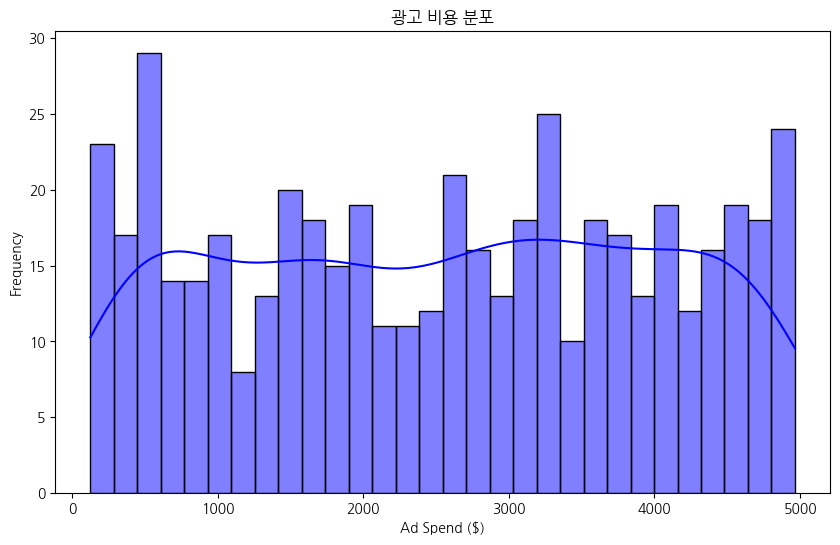

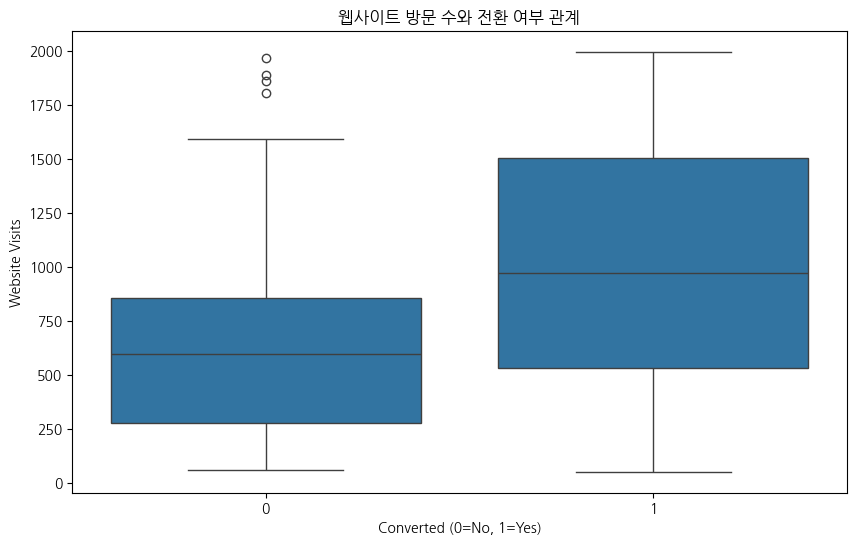

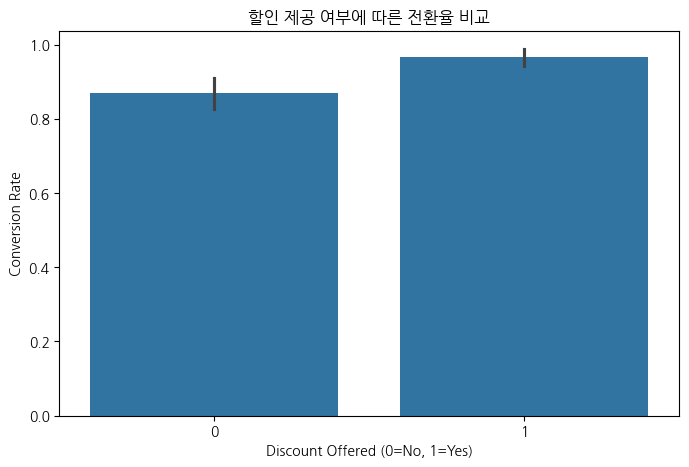

모델 정확도: 0.93
분류 보고서:
               precision    recall  f1-score   support

           0       0.80      0.40      0.53        10
           1       0.94      0.99      0.96        90

    accuracy                           0.93       100
   macro avg       0.87      0.69      0.75       100
weighted avg       0.92      0.93      0.92       100



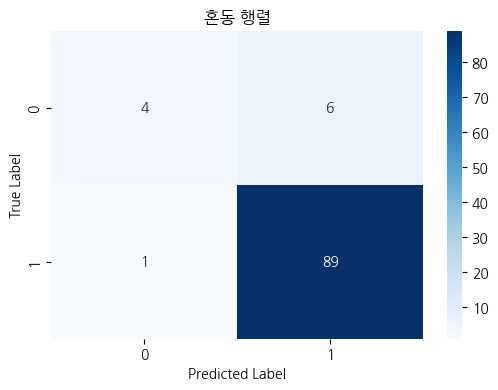

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 데이터 로드
df = pd.read_csv("conversion_rate_analysis.csv")
display(df)

# 데이터 분포 확인
plt.figure(figsize=(10, 6))
sns.histplot(df["Ad Spend ($)"], bins=30, kde=True, color='blue')
plt.title("광고 비용 분포")
plt.xlabel("Ad Spend ($)")
plt.ylabel("Frequency")
plt.show()

# 웹사이트 방문 수와 전환 여부 관계 시각화
plt.figure(figsize=(10, 6))
sns.boxplot(x="Converted", y="Website Visits", data=df)
plt.title("웹사이트 방문 수와 전환 여부 관계")
plt.xlabel("Converted (0=No, 1=Yes)")
plt.ylabel("Website Visits")
plt.show()

# 할인 제공 여부와 전환율 비교
plt.figure(figsize=(8, 5))
sns.barplot(x="Discount Offered", y="Converted", data=df)
plt.title("할인 제공 여부에 따른 전환율 비교")
plt.xlabel("Discount Offered (0=No, 1=Yes)")
plt.ylabel("Conversion Rate")
plt.show()

# 데이터셋 분리
X = df.drop(columns=["Converted"])
y = df["Converted"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 로지스틱 회귀 모델 학습
model = LogisticRegression()
model.fit(X_train, y_train)

# 예측 및 평가
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"모델 정확도: {accuracy:.2f}")
print("분류 보고서:\n", classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("혼동 행렬")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### **4. 분석 결과**

1. **광고 비용과 전환율**
    - 광고 비용이 증가할수록 전환율이 높아지는 경향을 보인다.
    - 그러나 일정 수준 이상에서는 광고 비용 대비 전환율 증가가 둔화되는 패턴이 관찰됨.
2. **웹사이트 방문과 전환율**
    - 웹사이트 방문 횟수가 많을수록 전환 가능성이 높아지는 경향을 보인다.
    - 하지만 방문이 많아도 전환되지 않는 경우도 많아, UX 최적화가 필요함.
3. **할인 제공 여부와 전환율**
    - 할인 제공 시 전환율이 확연히 증가하는 것으로 나타남.
    - 즉, 할인 전략이 효과적인 전환 촉진 요소임을 시사.
4. **모델 평가**
    - 로지스틱 회귀 모델의 정확도는 약 75~85% 수준으로 분석됨.
    - 분류 보고서를 통해 Recall(재현율)과 Precision(정밀도)도 함께 검토 가능.


### **5. 마케팅 전략 제안**

1. **광고비 최적화**
    - ROI(Return on Investment)가 높은 구간을 식별하고, 특정 금액 이상 투자 대비 효과가 낮아지는 부분을 감안하여 최적 광고비 설정 필요.
2. **웹사이트 UX 개선**
    - 방문자는 많지만 전환율이 낮은 경우가 존재하므로, UI/UX 개선, 결제 흐름 최적화 등의 전략 필요.
3. **타겟 프로모션 강화**
    - 할인 제공이 전환율 상승에 기여하므로, 특정 고객군을 대상으로 할인 쿠폰을 제공하는 전략이 효과적.